Project 2: Application of Convolutional Neural Networks (CNN) for Surface Defect Detection in Manufacturing


**Problem Statement**

In modern manufacturing industries, maintaining consistent product quality is a critical operational challenge. Surface defects in materials such as steel can significantly affect product reliability, structural integrity, and overall customer satisfaction.

 Traditionally, defect detection is performed through manual inspection, which is often time-consuming, labour-intensive, and susceptible to human error, especially in high-volume
 production environments.
With the increasing demand for efficient quality control systems, industries require automated solutions capable of accurately identifying and classifying defects in real time. Computer vision and deep learning technologies provide a promising approach to address this challenge.

Therefore, the primary problem addressed in this study is the development of an automated defect classification system using Convolutional Neural Networks (CNN) that can analyse image data and accurately detect different types of steel surface defects. The goal is to enhance inspection accuracy, reduce manual dependency, and support more efficient quality control processes within manufacturing operations.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving neu_surface_defect_database.zip to neu_surface_defect_database.zip


In [ ]:
!unzip neu_surface_defect_database.zip

Archive:  neu_surface_defect_database.zip
  inflating: NEU-DET/train/annotations/crazing_1.xml  
  inflating: NEU-DET/train/annotations/crazing_10.xml  
  inflating: NEU-DET/train/annotations/crazing_100.xml  
  inflating: NEU-DET/train/annotations/crazing_101.xml  
  inflating: NEU-DET/train/annotations/crazing_102.xml  
  inflating: NEU-DET/train/annotations/crazing_103.xml  
  inflating: NEU-DET/train/annotations/crazing_104.xml  
  inflating: NEU-DET/train/annotations/crazing_105.xml  
  inflating: NEU-DET/train/annotations/crazing_106.xml  
  inflating: NEU-DET/train/annotations/crazing_107.xml  
  inflating: NEU-DET/train/annotations/crazing_108.xml  
  inflating: NEU-DET/train/annotations/crazing_109.xml  
  inflating: NEU-DET/train/annotations/crazing_11.xml  
  inflating: NEU-DET/train/annotations/crazing_110.xml  
  inflating: NEU-DET/train/annotations/crazing_111.xml  
  inflating: NEU-DET/train/annotations/crazing_112.xml  
  inflating: NEU-DET/train/annotations/crazing_113

In [ ]:
import os
print(os.listdir("/content/NEU-DET"))

['train', 'validation']


Import Libraries

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

Define Dataset Paths

In [ ]:
train_path = "/content/NEU-DET/train/images"
val_path = "/content/NEU-DET/validation/images"

Data Frame

In [ ]:
def create_dataframe(path):

    image_paths = []
    labels = []

    for class_name in os.listdir(path):

        class_folder = os.path.join(path,class_name)

        if os.path.isdir(class_folder):

            for img in os.listdir(class_folder):

                full_path = os.path.join(class_folder,img)

                image_paths.append(full_path)
                labels.append(class_name)

    df = pd.DataFrame({
        "filename":image_paths,
        "class":labels
    })

    return df


train_df = create_dataframe(train_path)
val_df = create_dataframe(val_path)

print(train_df.head())

                                            filename           class
0  /content/NEU-DET/train/images/pitted_surface/p...  pitted_surface
1  /content/NEU-DET/train/images/pitted_surface/p...  pitted_surface
2  /content/NEU-DET/train/images/pitted_surface/p...  pitted_surface
3  /content/NEU-DET/train/images/pitted_surface/p...  pitted_surface
4  /content/NEU-DET/train/images/pitted_surface/p...  pitted_surface


Dataset Distribution Visualization

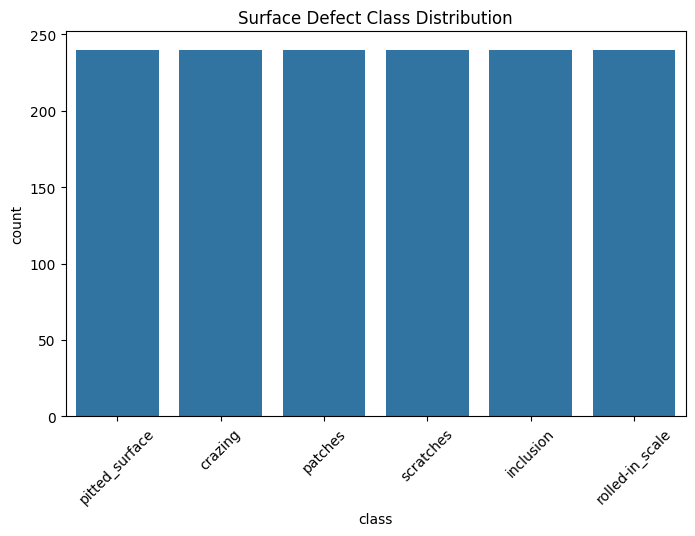

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=train_df,x="class")
plt.title("Surface Defect Class Distribution")
plt.xticks(rotation=45)
plt.show()

Visualize Sample Images

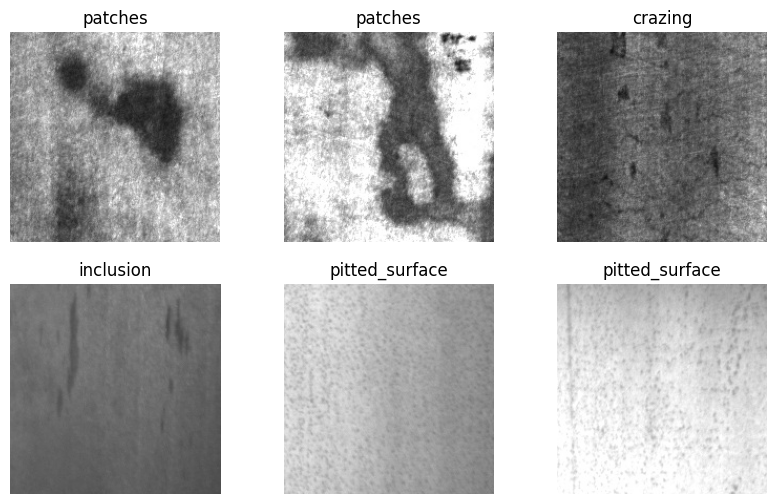

In [ ]:
plt.figure(figsize=(10,6))

for i in range(6):

    idx = random.randint(0,len(train_df)-1)

    img = cv2.imread(train_df.filename.iloc[idx])
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(train_df["class"].iloc[idx])
    plt.axis("off")

plt.show()

Model Summary

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,406 (10.49 MB)

 Trainable params: 2,749,958 (10.49 MB)

 Non-trainable params: 448 (1.75 KB)

Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

Load Images for CNN

In [ ]:
train_data = train_gen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

val_data = val_gen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

Found 1440 validated image filenames belonging to 6 classes.
Found 360 validated image filenames belonging to 6 classes.


In [ ]:
print(train_data.class_indices)

{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


Build CNN Model

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(256,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(256,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(6,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9389 - loss: 0.2250 - val_accuracy: 0.7583 - val_loss: 0.9002
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9361 - loss: 0.1806 - val_accuracy: 0.3250 - val_loss: 48.0972
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9403 - loss: 0.1809 - val_accuracy: 0.4722 - val_loss: 2.2743
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9361 - loss: 0.1965 - val_accuracy: 0.1694 - val_loss: 94.0595
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9583 - loss: 0.1446 - val_accuracy: 0.2528 - val_loss: 7.6541
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9472 - loss: 0.1367 - val_accuracy: 0.4583 - val_loss: 3.4118
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9549 - loss: 0.1432 - val_accuracy: 0.5639 - val_loss: 1.7580
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9563 - loss: 0.1259 - val_accuracy: 0.8361 - val_los

Plot Accuracy & Loss

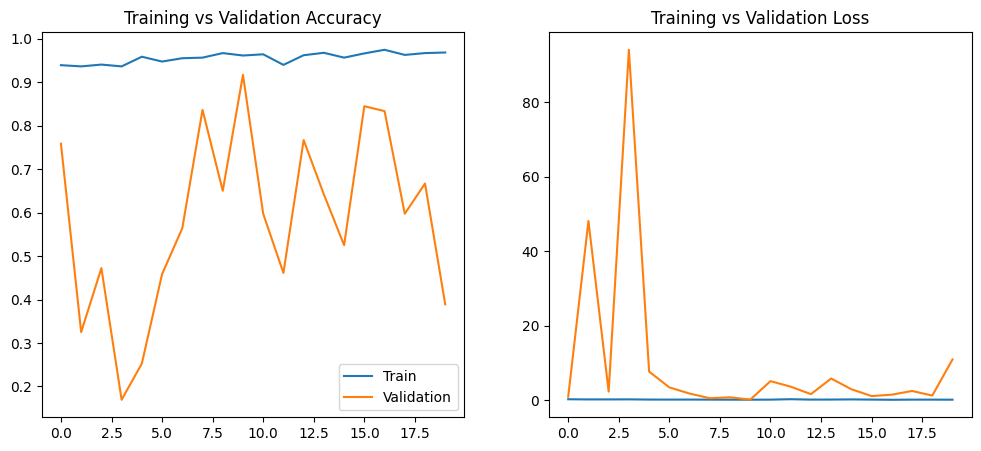

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation Loss")

plt.show()

Confusion Matrix

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 308ms/step


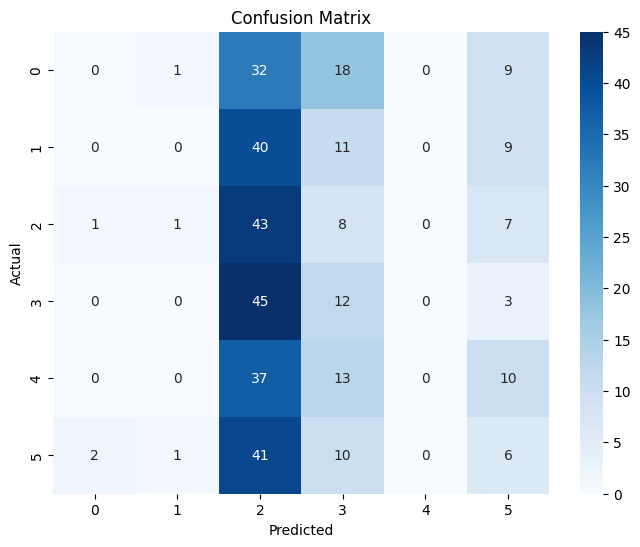

In [ ]:
from sklearn.metrics import confusion_matrix

pred = model.predict(val_data)

pred_classes = np.argmax(pred,axis=1)
true_classes = val_data.classes

cm = confusion_matrix(true_classes,pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Dataset Distribution Graph

<Axes: xlabel='class', ylabel='count'>

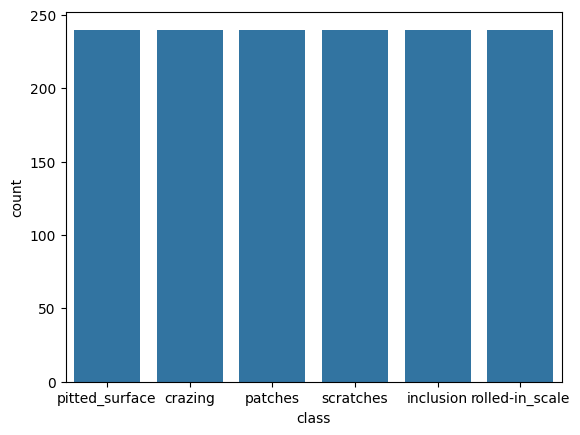

In [ ]:
sns.countplot(data=train_df,x="class")

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(true_classes,pred_classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.00      0.00      0.00        60
           2       0.18      0.72      0.29        60
           3       0.17      0.20      0.18        60
           4       0.00      0.00      0.00        60
           5       0.14      0.10      0.12        60

    accuracy                           0.17       360
   macro avg       0.08      0.17      0.10       360
weighted avg       0.08      0.17      0.10       360



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Sample Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


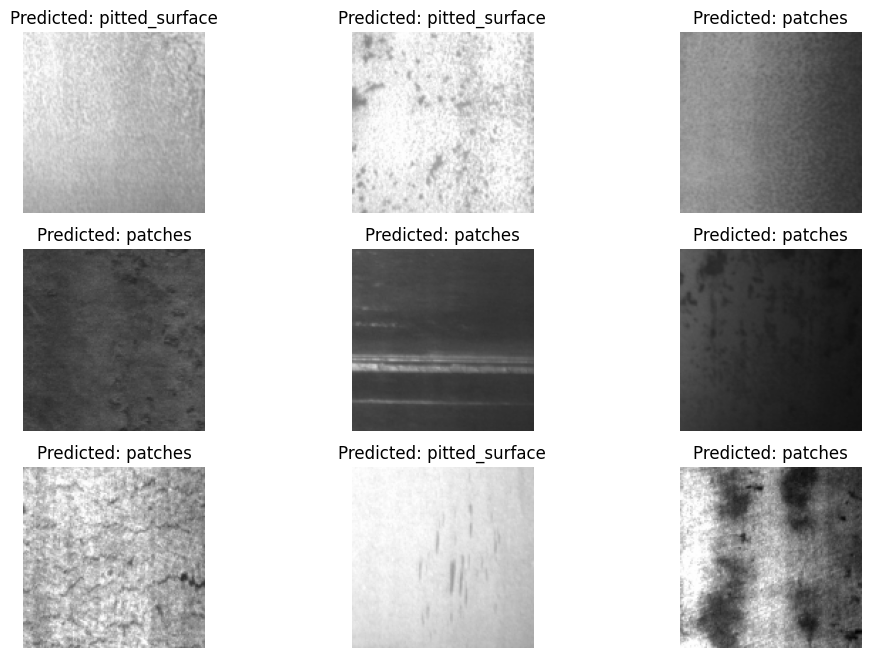

In [ ]:
plt.figure(figsize=(12,8))

for i in range(9):

    idx = random.randint(0,len(val_df)-1)

    img_path = val_df.filename.iloc[idx]

    img = cv2.imread(img_path)
    img_resized = cv2.resize(img,(128,128))

    img_input = img_resized/255.0
    img_input = np.expand_dims(img_input,axis=0)

    prediction = model.predict(img_input)

    pred_label = list(train_data.class_indices.keys())[np.argmax(prediction)]

    plt.subplot(3,3,i+1)
    plt.imshow(cv2.cvtColor(img_resized,cv2.COLOR_BGR2RGB))
    plt.title("Predicted: "+pred_label)
    plt.axis("off")

plt.show()

ROC Curve

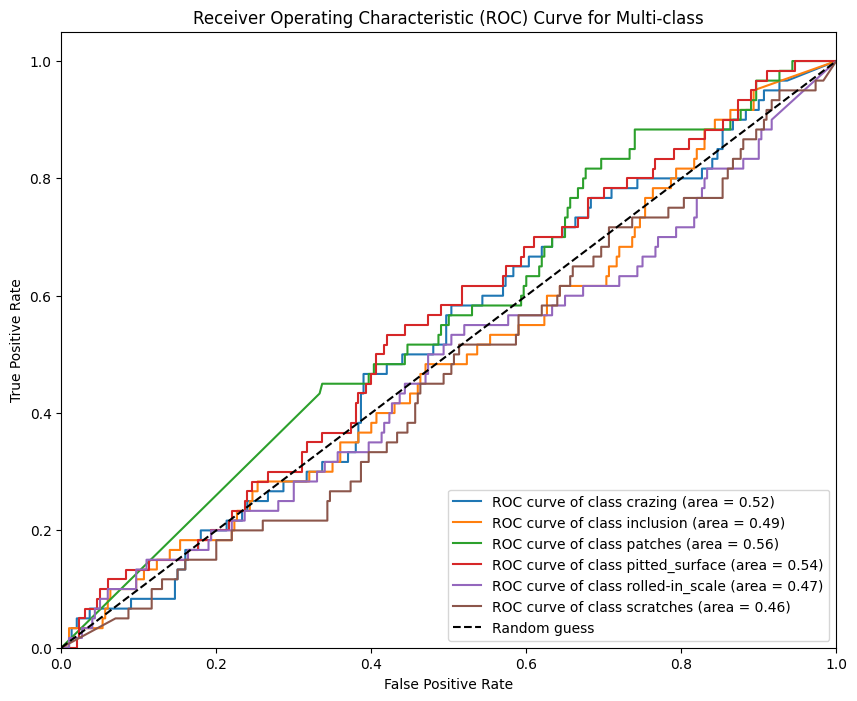

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# One-hot encode the true labels
encoder = OneHotEncoder(sparse_output=False)
true_classes_onehot = encoder.fit_transform(np.array(true_classes).reshape(-1, 1))

# Get the number of classes
n_classes = true_classes_onehot.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(true_classes_onehot[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {list(train_data.class_indices.keys())[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")
plt.show()

Specificity

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(true_classes, pred_classes)

specificity = []

for i in range(len(cm)):

    tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
    fp = np.sum(cm[:,i]) - cm[i,i]

    specificity.append(tn/(tn+fp))

print("Specificity per class:", specificity)
print("Average Specificity:", np.mean(specificity))

Specificity per class: [np.float64(0.99), np.float64(0.99), np.float64(0.35), np.float64(0.8), np.float64(1.0), np.float64(0.8733333333333333)]
Average Specificity: 0.8338888888888888


Log Loss

In [ ]:
from sklearn.metrics import log_loss

logloss = log_loss(true_classes, pred)

print("Log Loss:", logloss)

Log Loss: 11.011184293356528


Cohen Kappa

In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(true_classes, pred_classes)

print("Cohen Kappa Score:", kappa)

Cohen Kappa Score: 0.0033333333333331883


Convergence Rate



In [ ]:
epochs_run = len(history.history['loss'])

print("Model converged in", epochs_run, "epochs")

Model converged in 20 epochs


Memory usage

In [ ]:
import tensorflow as tf

print("Model Memory Usage (MB):", model.count_params()*4/1024**2)

Model Memory Usage (MB): 10.491966247558594
